In [1]:
# Librerías
import numpy as np
import os
from PIL import Image

In [2]:
# Establecer ruta correspondiente
path = "C:\\Users\\175199\\Redes-Neuronales\\02 Red Neuronal Simple\\laboratorios\\Lab 3\\17flowers"

En el siguiente enlace encontrará la base de datos y el tipo de flor de cada categoría

[Categorías](https://www.robots.ox.ac.uk/~vgg/data/flowers/17/index.html)

In [3]:
# Elegir las clases correspondientes, enteros entre 0 y 16
classes = [3, 5, 7, 9, 14]

In [4]:
# Extraer las imágenes correspondientes a las clases seleccionadas
n_per_class = 80
images = []
images_resized = []
labels = []
target_size = (64, 64)
for c in classes:
    start = c * n_per_class
    end = (c + 1) * n_per_class
    for i in range(start, end):
        name_file = f"{path}\\jpg\\image_{i+1:04d}.jpg"
        img = Image.open(name_file)
        images.append(img)
        img_resized = img.convert("RGB").resize(target_size)
        images_resized.append(img_resized)
        labels.append(c)

Ejemplo de imagenes

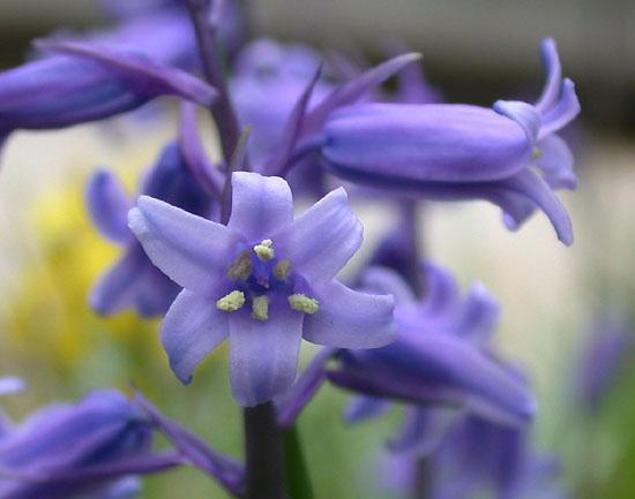

In [5]:
# Tamaño original
images[0]

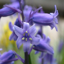

In [6]:
# Compresión y homogeneización de la imagen
images_resized[0]

In [7]:
# Convertir a vector de dimensión 128*128*3=49152 o 64*64*3=12288
X = [np.array(img).flatten() for img in images_resized]
X = np.array(X)

In [8]:
ones = np.ones((X.shape[0], 1))

In [9]:
X = np.concatenate((X, ones), axis=1)

In [10]:
zeros = np.zeros((X.shape[1], 1))
zeros = zeros.flatten()

In [21]:
clasificaciones = len(classes)
imagenes = X.shape[0]
pixeles = X.shape[1]
print(f"Clasificaciones: {clasificaciones}, Imágenes: {imagenes}, Pixeles: {pixeles}, Pixeles * clasificaciones -1 : {pixeles * (clasificaciones - 1)}")

Clasificaciones: 5, Imágenes: 400, Pixeles: 12289, Pixeles * clasificaciones -1 : 49156


In [19]:
# crear la matriz gigante de ceros
ZEROS = np.zeros((pixeles * (clasificaciones-1), 1)).flatten()
matrizZeros = np.tile(ZEROS, (clasificaciones-1, 1))
matrizZeros.shape

(4, 49156)

In [22]:
filas = matrizZeros.shape[0]
columnas = matrizZeros.shape[1]

# Para la primera imagen

In [ ]:
-X[0]

array([-102.,  -99.,  -93., ..., -105.,  -23.,   -1.])

In [48]:
vectorCorrecto = np.tile(X[0], (filas, 1))
vectorCorrecto

array([[102.,  99.,  93., ..., 105.,  23.,   1.],
       [102.,  99.,  93., ..., 105.,  23.,   1.],
       [102.,  99.,  93., ..., 105.,  23.,   1.],
       [102.,  99.,  93., ..., 105.,  23.,   1.]])

In [49]:
primeraColumna = np.tile(zeros, (filas, 1))
primeraColumna[0, :] = -X[0]
primeraColumna

array([[-102.,  -99.,  -93., ..., -105.,  -23.,   -1.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.]])

In [50]:
segundaColumna = np.tile(zeros, (filas, 1))
segundaColumna[1, :] = -X[0]
segundaColumna

array([[   0.,    0.,    0., ...,    0.,    0.,    0.],
       [-102.,  -99.,  -93., ..., -105.,  -23.,   -1.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.]])

In [51]:
columnas = []
for i in range(clasificaciones - 1):
    nuevaColumna = np.tile(zeros, (filas, 1))
    nuevaColumna[i, :] = -X[0]
    columnas.append(nuevaColumna)

In [52]:
columnas[2]

array([[   0.,    0.,    0., ...,    0.,    0.,    0.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.],
       [-102.,  -99.,  -93., ..., -105.,  -23.,   -1.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.]])

In [66]:
matrizClase1 = np.concatenate([vectorCorrecto, columnas[0], columnas[1], columnas[2], columnas[3]], axis=1)
matrizClase2 = np.concatenate([columnas[0], vectorCorrecto, columnas[1], columnas[2], columnas[3]], axis=1)
matrizClase3 = np.concatenate([columnas[0], columnas[1], vectorCorrecto, columnas[2], columnas[3]], axis=1)
matrizClase3 = np.concatenate([columnas[0], columnas[1], vectorCorrecto, columnas[2], columnas[3]], axis=1)
matrizClase4 = np.concatenate([columnas[0], columnas[1], columnas[2], vectorCorrecto, columnas[3]], axis=1)
matrizClase5 = np.concatenate([columnas[0], columnas[1], columnas[2], columnas[3], vectorCorrecto], axis=1)
matrizClase5


array([[-102.,  -99.,  -93., ...,  105.,   23.,    1.],
       [   0.,    0.,    0., ...,  105.,   23.,    1.],
       [   0.,    0.,    0., ...,  105.,   23.,    1.],
       [   0.,    0.,    0., ...,  105.,   23.,    1.]])

In [ ]:

matrizClase1 = np.concatenate([vectorCorrecto, columnas[0], columnas[1], columnas[2], columnas[3]], axis=1)
matrizClase2 = np.concatenate([columnas[0], vectorCorrecto, columnas[1], columnas[2], columnas[3]], axis=1)
matrizClase3 = np.concatenate([columnas[0], columnas[1], vectorCorrecto, columnas[2], columnas[3]], axis=1)
matrizClase3 = np.concatenate([columnas[0], columnas[1], vectorCorrecto, columnas[2], columnas[3]], axis=1)
matrizClase4 = np.concatenate([columnas[0], columnas[1], columnas[2], vectorCorrecto, columnas[3]], axis=1)
matrizClase5 = np.concatenate([columnas[0], columnas[1], columnas[2], columnas[3], vectorCorrecto], axis=1)
matrizClase5


switch = {
    0: matrizClase1,
    1: matrizClase2,
    2: matrizClase3,
    3: matrizClase4,
    4: matrizClase5
}

In [ ]:
k = 4
cols = []
for j in range(clasificaciones):
    if k == j:
        cols.append(vectorCorrecto)
    else:
        cols.append(columnas[j if j < k else j-1])
matrizClaseK = np.concatenate(cols, axis=1)
matrizClaseK

array([[-102.,  -99.,  -93., ...,  105.,   23.,    1.],
       [   0.,    0.,    0., ...,  105.,   23.,    1.],
       [   0.,    0.,    0., ...,  105.,   23.,    1.],
       [   0.,    0.,    0., ...,  105.,   23.,    1.]])

# Para todas las imagenes

In [72]:
nimagen = 0

vectorCorrecto = np.tile(X[nimagen], (filas, 1))

# Crear las otras columnas para la matriz grande
columnas = []
for i in range(clasificaciones - 1):
    nuevaColumna = np.tile(zeros, (filas, 1))
    nuevaColumna[i, :] = -X[nimagen]
    columnas.append(nuevaColumna)

# Unir todo en la matriz grande
k = 4
cols = []
for j in range(clasificaciones):
    if k == j:
        cols.append(vectorCorrecto)
    else:
        cols.append(columnas[j if j < k else j-1])
matrizClaseK = np.concatenate(cols, axis=1)
matrizClaseK

array([[-102.,  -99.,  -93., ...,  105.,   23.,    1.],
       [   0.,    0.,    0., ...,  105.,   23.,    1.],
       [   0.,    0.,    0., ...,  105.,   23.,    1.],
       [   0.,    0.,    0., ...,  105.,   23.,    1.]])

In [73]:
from perceptron import Perceptron